In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Demand parameters
mu = 10000
sigma = 2500

# Economic parameters
p = 988.77
c = 800
s = 500

# CLSC parameters
v_reuse = 20
v_recycle = -15
v_recover = -8

c_collect = 15

In [3]:
Q_values = np.arange(2500, 15001, 250)

In [4]:
def expected_lost_sales(Q, mu, sigma):

    z = (Q - mu) / sigma

    L = norm.pdf(z) - z * (1 - norm.cdf(z))

    return sigma * L


def expected_sales(Q, mu, sigma):

    return mu - expected_lost_sales(Q, mu, sigma)


def expected_inventory(Q, mu, sigma):

    return Q - expected_sales(Q, mu, sigma)

In [5]:
sales_list = []
inventory_list = []
lost_sales_list = []

for Q in Q_values:

    sales = expected_sales(Q, mu, sigma)

    inventory = expected_inventory(Q, mu, sigma)

    lost_sales = expected_lost_sales(Q, mu, sigma)

    sales_list.append(sales)
    inventory_list.append(inventory)
    lost_sales_list.append(lost_sales)

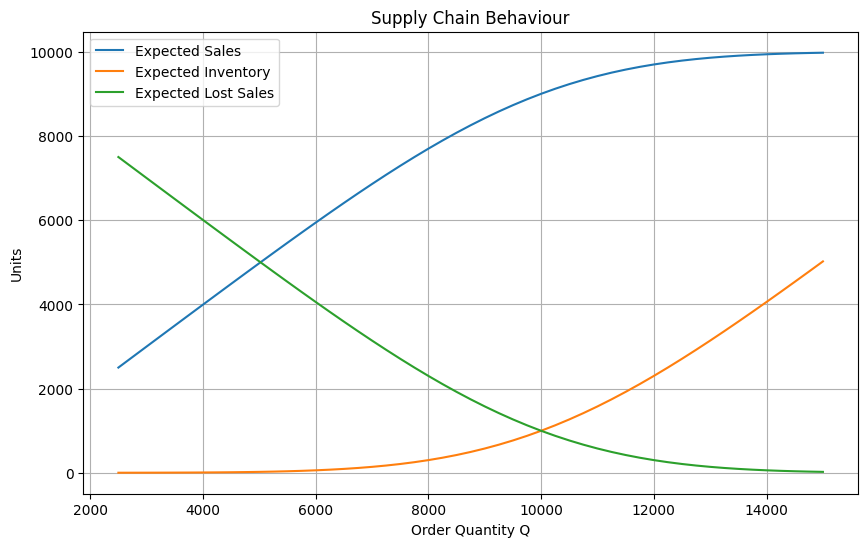

In [6]:
plt.figure(figsize=(10,6))

plt.plot(Q_values, sales_list,
         label="Expected Sales")

plt.plot(Q_values, inventory_list,
         label="Expected Inventory")

plt.plot(Q_values, lost_sales_list,
         label="Expected Lost Sales")

plt.xlabel("Order Quantity Q")
plt.ylabel("Units")

plt.title("Supply Chain Behaviour")

plt.legend()

plt.grid(True)

plt.show()

In [7]:
def lsc_profit(Q):

    sales = expected_sales(Q, mu, sigma)

    inventory = expected_inventory(Q, mu, sigma)

    profit = ((p - c) * sales) - ((c - s) * inventory)

    return profit

In [8]:
lsc_profit_values = []

for Q in Q_values:

    lsc_profit_values.append(
        lsc_profit(Q)
    )

In [9]:
best_idx = np.argmax(lsc_profit_values)

best_Q_lsc = Q_values[best_idx]

best_profit_lsc = lsc_profit_values[best_idx]

print("Optimal Q =", best_Q_lsc)
print("Profit =", round(best_profit_lsc,2))

Optimal Q = 9250
Profit = 1420160.27


In [10]:
def clsc_profit(Q):

    sales = expected_sales(Q, mu, sigma)

    inventory = expected_inventory(Q, mu, sigma)

    # Leftover inventory
    leftover_value = inventory * v_reuse

    # Sold products recovery
    recovery_value = sales * v_recover

    profit = (

        (p-c)*sales

        - c*inventory

        + leftover_value

        - c_collect*sales

        + recovery_value

    )

    return profit

In [11]:
clsc_profit_values = []

for Q in Q_values:

    clsc_profit_values.append(
        clsc_profit(Q)
    )

In [12]:
best_idx = np.argmax(clsc_profit_values)

best_Q_clsc = Q_values[best_idx]

best_profit_clsc = clsc_profit_values[best_idx]

print("Optimal CLSC Quantity =", best_Q_clsc)

print("Profit =", round(best_profit_clsc,2))

Optimal CLSC Quantity = 7750
Profit = 1047255.61


In [13]:
comparison = pd.DataFrame({

    "Model":
    ["Linear","Closed Loop"],

    "Optimal Q":
    [best_Q_lsc,best_Q_clsc],

    "Profit":
    [best_profit_lsc,best_profit_clsc]

})

comparison

,Model,Optimal Q,Profit
0,Linear,9250,1.420160e+06
1,Closed Loop,7750,1.047256e+06


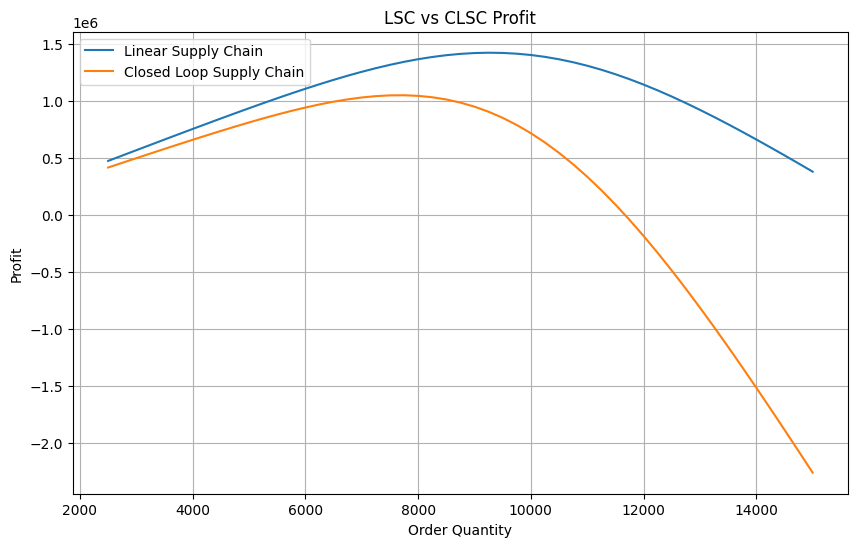

In [14]:
plt.figure(figsize=(10,6))

plt.plot(Q_values,
         lsc_profit_values,
         label="Linear Supply Chain")

plt.plot(Q_values,
         clsc_profit_values,
         label="Closed Loop Supply Chain")

plt.xlabel("Order Quantity")

plt.ylabel("Profit")

plt.title("LSC vs CLSC Profit")

plt.legend()

plt.grid(True)

plt.show()